In [4]:
import os
import numpy as np
from matplotlib import pyplot as plt

In [5]:
stim_dir = '../../../data/stimuli'

os.listdir(stim_dir)

['QDSpy', 'moving_bar', 'mouse_cam_movies', 'global_chirp', 'README.md']

In [6]:
chirp_movie = np.load(os.path.join(stim_dir, 'global_chirp', 'chirp1000_setup3_movie_and_trigger.npz'))
bar_movie = np.load(os.path.join(stim_dir, 'moving_bar', 'DS_setup3_movie_and_trigger.npz'))

# Chirp

In [7]:
def plot_chirp(chirp, chirp_trigger, chirp_time):
    fig, axs = plt.subplots(1, 2, figsize=(12, 2), width_ratios=(1, 3))

    t_s = 3

    ax = axs[0]
    h, w = chirp.shape[1:3]
    im = ax.imshow(chirp[60*t_s], vmin=0, vmax=254, extent=(-w/2, w/2, h/2, -h/2))
    plt.colorbar(im, ax=ax, ticks=[0, 254])
    ax.set(xlabel='left <-> right\n[pix=10 µm]', ylabel='front <-> back\n[pix=10 µm]', title=f't={t_s}s')

    ax = axs[1]
    ax.plot(chirp_time, chirp[:, chirp.shape[1]//2, chirp.shape[2]//2], label='Int. @ Center')
    ax.vlines(chirp_time[chirp_trigger], -70, -20, color='r', label='Trigger')
    ax.set(xlabel='Time [s]', ylabel='Intensity')
    ax.set_yticks([0, 100, 200, 254])
    ax.set_xticks([0, 2, 5, 8, 10, 18, 20, 28, 30, 33])
    ax.legend(loc='upper right')

    return fig, axs

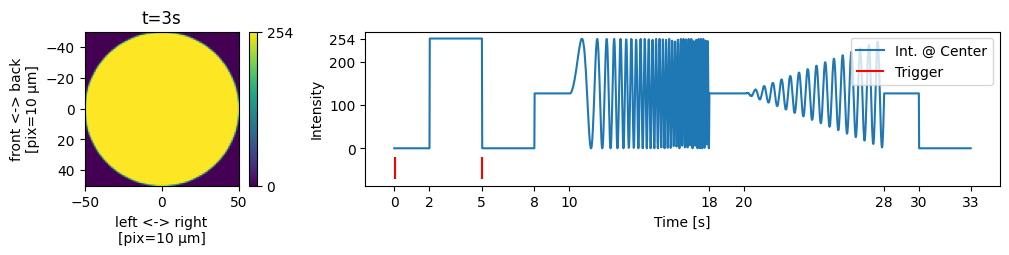

In [8]:
fig, axs = plot_chirp(
    chirp=chirp_movie['stimulus'],
    chirp_trigger=chirp_movie['trigger'],
    chirp_time=chirp_movie['time']
)

# Moving bar

Please read the Readme to find out what the directions mean with respect to the retina.

In [9]:
def plot_mb(bar, bar_trigger, time_bar):
    fig, axs = plt.subplot_mosaic(
        """
        ABCDE
        FFFFF
        """,
        figsize=(12, 4)
    )

    ax = axs['A']
    h, w = bar.shape[1:3]
    im = ax.imshow(np.mean(bar, axis=0), vmin=0, extent=(-w/2, w/2, h/2, -h/2))
    ax.set(xlabel='left <-> right\n[pix=10 µm]', ylabel='front <-> back\n[pix=10 µm]', title='mean')
    plt.colorbar(im, ax=ax)

    all_ts = [4.3, 8.3, 12.3, 16.3]

    for i, t_s in enumerate(all_ts):
        ax = axs["BCDE"[i]]
        ax.set_title(f't={t_s}s')
        h, w = bar.shape[1:3]
        im = ax.imshow(bar[int(60*t_s)], vmin=0, vmax=255, extent=(-w/2, w/2, h/2, -h/2))
        plt.colorbar(im, ax=ax, ticks=[0, 255])

    ax = axs['F']
    ax.plot(time_bar, bar[:, bar.shape[1] // 2, bar.shape[2] // 2], label='Int. @ Center')
    ax.vlines(time_bar[bar_trigger], -70, -20, color='r', label='Trigger')
    ax.vlines(all_ts, ymin=260, ymax=300, color='k', label='Shown frames')
    ax.set_xticks(np.arange(int(max(time_bar))))
    ax.set(xlabel='Time [s]', ylabel='Intensity')
    ax.set_yticks([0, 100, 200, 255])
    ax.legend(loc='lower right')

    for i, deg in enumerate([0, 180, 45, 225, 90, 270, 135, 315]):
        ax.text((4.5+4*i), 260, f"{deg}°", ha='left', va='bottom')

    plt.tight_layout()

    return fig, axs

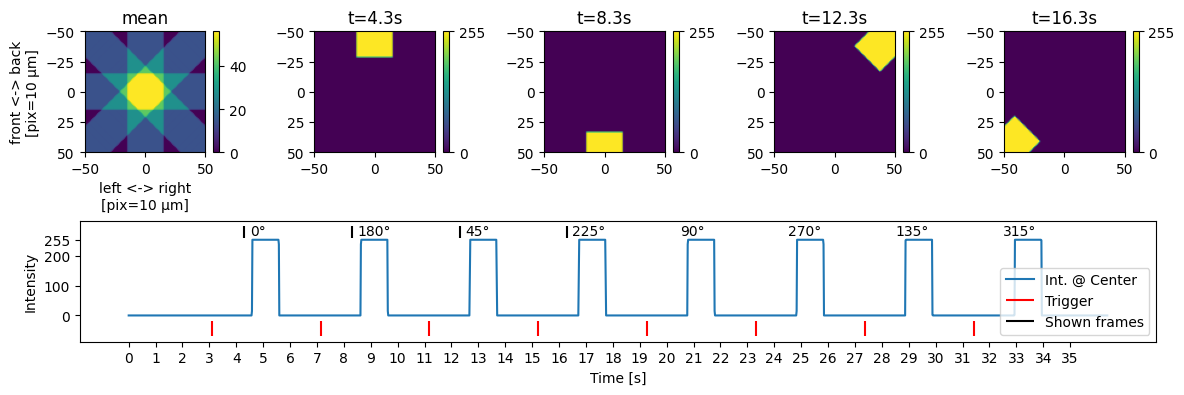

In [11]:
fig, axs = plot_mb(
    bar=bar_movie['stimulus'],
    bar_trigger=bar_movie['trigger'],
    time_bar=bar_movie['time']
)